In [1]:
!pip install yfinance statsmodels

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools

from statsmodels.tsa.stattools import coint
from datetime import datetime

plt.style.use("seaborn-v0_8")

In [ ]:
stocks = [

"AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","NFLX",

"JPM","BAC","WFC","GS","MS","C",

"XOM","CVX","COP",

"KO","PEP","PG","WMT","COST",

"JNJ","PFE","MRK","ABBV",

"V","MA","PYPL",

"INTC","AMD","QCOM","AVGO","CSCO",

"DIS","CMCSA","NKE","SBUX",

"BA","CAT","MMM","GE"
]


In [ ]:
start = "2010-01-01"
end = datetime.today().strftime("%Y-%m-%d")

tickers = " ".join(stocks)

raw = yf.download(
    tickers,
    start=start,
    end=end,
    group_by="ticker",
    threads=True,
    auto_adjust=False
)


print("Raw shape:", raw.shape)


[*********************100%***********************]  42 of 42 completed

Raw shape: (4054, 252)


In [ ]:
prices = pd.DataFrame()
failed = []


for s in stocks:

    try:
        close = raw[s]["Close"]

        if close.isna().all():
            failed.append(s)
            continue

        prices[s] = close

    except:
        failed.append(s)


prices = prices.dropna()


print("Rows:", len(prices))
print("Stocks:", prices.shape[1])
print("Failed:", failed)


Rows: 2670
Stocks: 42
Failed: []


In [ ]:
returns = prices.pct_change().dropna()

corr = returns.corr()

corr_thresh = 0.7

candidates = []


for i, j in itertools.combinations(corr.columns, 2):

    c = corr.loc[i,j]

    if c > corr_thresh:

        candidates.append((i,j,c))


print("High-corr pairs:", len(candidates))


High-corr pairs: 20


In [ ]:
results = []


for s1, s2, c in candidates:

    x = prices[s1]
    y = prices[s2]

    score, pval, _ = coint(x,y)

    if pval < 0.05:

        results.append({
            "Stock1": s1,
            "Stock2": s2,
            "Corr": round(c,3),
            "pval": round(pval,4)
        })


pairs_df = pd.DataFrame(results)

pairs_df = pairs_df.sort_values("pval")

pairs_df.head(10)


,Stock1,Stock2,Corr,pval
0,V,MA,0.897,0.002


In [ ]:
best = pairs_df.iloc[0]

stock1 = best["Stock1"]
stock2 = best["Stock2"]

print("Selected Pair:", stock1, "-", stock2)


Selected Pair: V - MA


In [ ]:
# Fixed hedge ratio (best for V-MA)

X = sm.add_constant(prices[stock1])
model = sm.OLS(prices[stock2], X).fit()

beta = model.params[1]

print("Fixed Beta:", round(beta,4))



Fixed Beta: 1.789


/tmp/ipython-input-1623994091.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


In [ ]:
s1 = prices[stock1]
s2 = prices[stock2]

spread = s2 - beta * s1



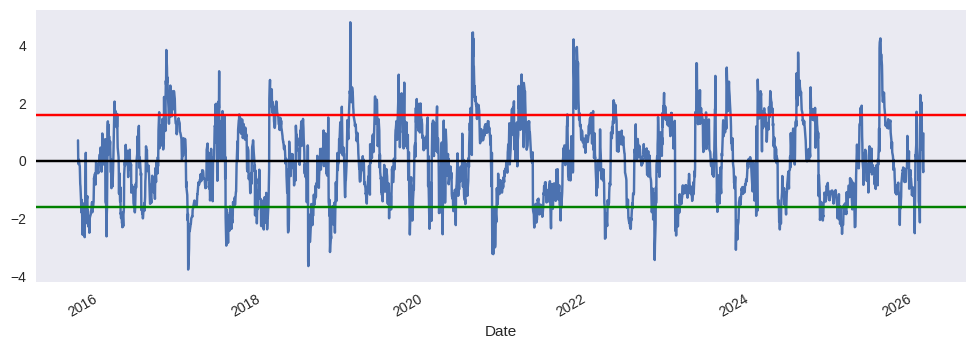

In [ ]:
mean = spread.rolling(60).mean()
std = spread.rolling(60).std()

z = (spread-mean)/std


z.plot(figsize=(12,4))
plt.axhline(1.6,color="red")
plt.axhline(-1.6,color="green")
plt.axhline(0,color="black")
plt.grid()
plt.show()


In [ ]:
entry = 1.6
exit = 0.5

pos = pd.Series(0,index=z.index)


pos[z>entry] = -1
pos[z<-entry] = 1
pos[abs(z)<exit] = 0


pos = pos.ffill().fillna(0)


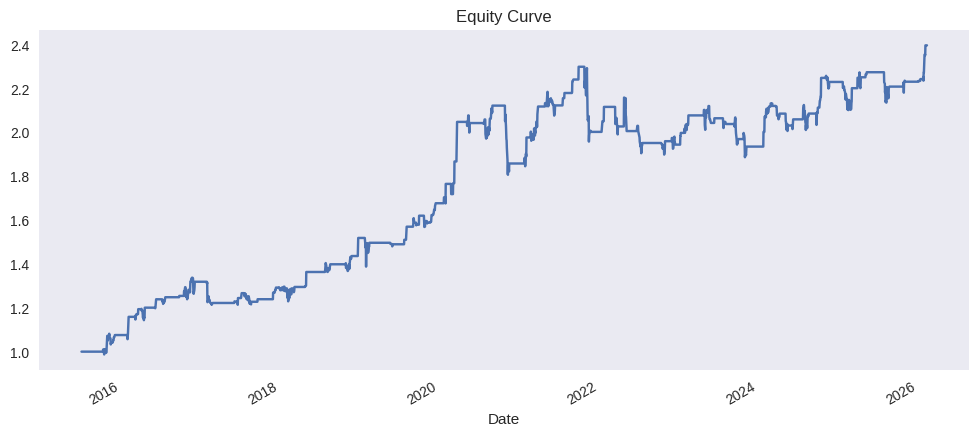

In [ ]:
r1 = s1.pct_change()
r2 = s2.pct_change()

raw_ret = r2 - beta*r1


strategy_ret = pos.shift(1)*raw_ret

strategy_ret = strategy_ret.dropna()


equity = (1+strategy_ret).cumprod()


equity.plot(figsize=(12,5),title="Equity Curve")
plt.grid()
plt.show()


In [ ]:
sharpe = np.sqrt(252)*strategy_ret.mean()/strategy_ret.std()

dd = (equity/equity.cummax()-1).min()

ret = equity.iloc[-1]-1


print("Sharpe:",round(sharpe,2))
print("Max DD:",round(dd*100,2),"%")
print("Return:",round(ret*100,2),"%")


Sharpe: 0.75
Max DD: -17.95 %
Return: 139.77 %


In [ ]:
def monte_carlo(r,n=5000,d=252):

    sims=[]

    for _ in range(n):

        s=np.random.choice(r,d,True)

        sims.append((1+s).cumprod())

    return np.array(sims)


mc = monte_carlo(strategy_ret)


final = mc[:,-1]


print("Worst:",round(np.percentile(final,5),2))
print("Median:",round(np.median(final),2))
print("Best:",round(np.percentile(final,95),2))
print("Loss Prob:",round(np.mean(final<1)*100,2),"%")


Worst: 0.9
Median: 1.08
Best: 1.32
Loss Prob: 25.04 %


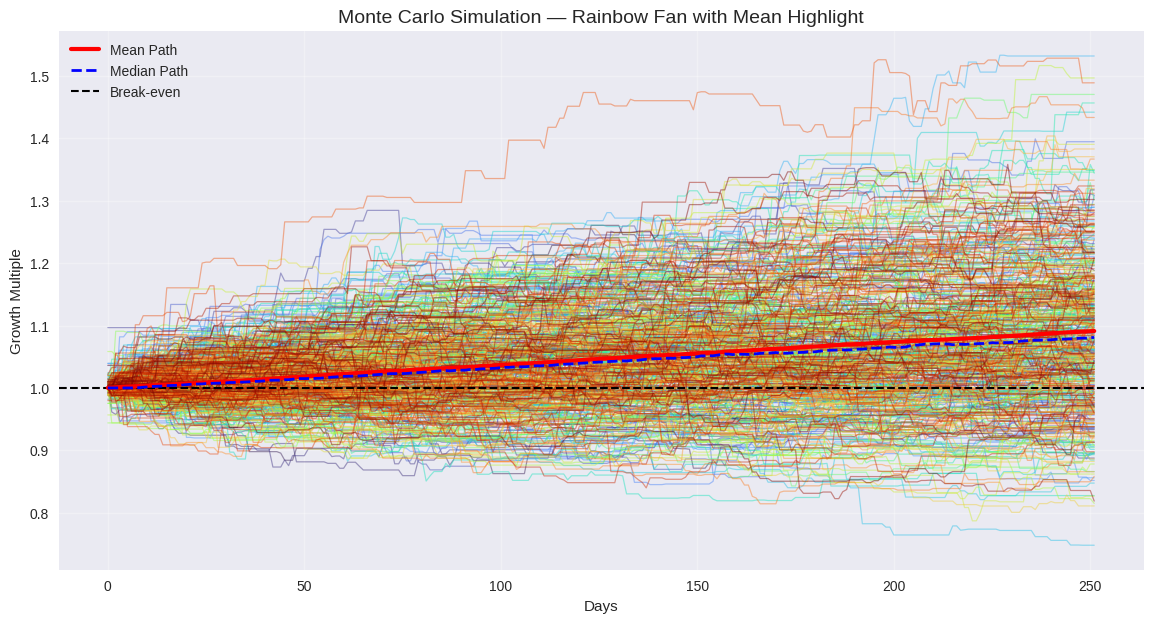

In [ ]:
plt.figure(figsize=(14,7))

# Limit paths for clarity
num_paths = min(500, len(mc))

# Colors
colors = plt.cm.turbo(np.linspace(0, 1, num_paths))


# Plot all simulations
for i in range(num_paths):

    plt.plot(
        mc[i],
        color=colors[i],
        alpha=0.45,      # keep background light
        linewidth=0.9
    )


# ---- Mean / Median Path ----
mean_path = mc.mean(axis=0)
median_path = np.median(mc, axis=0)


# Plot mean (main highlight)
plt.plot(
    mean_path,
    color="red",
    linewidth=3,
    label="Mean Path",
    zorder=5
)


# Plot median (optional, dashed)
plt.plot(
    median_path,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Median Path",
    zorder=5
)


# Break-even
plt.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Break-even"
)


plt.title("Monte Carlo Simulation — Rainbow Fan with Mean Highlight", fontsize=14)
plt.xlabel("Days")
plt.ylabel("Growth Multiple")

plt.grid(alpha=0.3)
plt.legend()
plt.show()


